In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
bios = pd.read_csv("bios.csv")

In [3]:
bios.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25


In [4]:
bios.info()

<class 'pandas.DataFrame'>
RangeIndex: 145500 entries, 0 to 145499
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   athlete_id    145500 non-null  int64  
 1   name          145500 non-null  str    
 2   born_date     143693 non-null  str    
 3   born_city     110908 non-null  str    
 4   born_region   110908 non-null  str    
 5   born_country  110908 non-null  str    
 6   NOC           145499 non-null  str    
 7   height_cm     106651 non-null  float64
 8   weight_kg     102070 non-null  float64
 9   died_date     33940 non-null   str    
dtypes: float64(2), int64(1), str(7)
memory usage: 18.5 MB


In [5]:
bios.isna().sum()

athlete_id           0
name                 0
born_date         1807
born_city        34592
born_region      34592
born_country     34592
NOC                  1
height_cm        38849
weight_kg        43430
died_date       111560
dtype: int64

In [6]:
bios_new = bios.copy()

In [7]:
bios_new["born_date"]= pd.to_datetime(bios["born_date"], errors="coerce")
bios_new["died_date"]= pd.to_datetime(bios["died_date"], errors="coerce")


In [8]:
for col in ["born_city", "born_region", "born_country", "NOC", "name"]:
    bios_new[col] = bios_new[col].fillna("Unknown").astype("string").str.strip()

In [9]:
bios_new.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaT
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25


In [10]:
import unicodedata
def quitar_tildes(texto):
    if isinstance(texto, str):
        texto = unicodedata.normalize("NFD", texto)
        return "".join (c for c in texto if not unicodedata.combining(c))
    return texto

In [11]:
cols =["name","born_city","born_region","NOC"]

for c in cols:
    bios_new[c] = bios_new[c].astype("string").str.strip().map(quitar_tildes)

In [12]:
bios_new

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
0,1,Jean-Francois Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaT
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrenees-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25
...,...,...,...,...,...,...,...,...,...,...
145495,149222,Polina Luchnikova,2002-01-30,Serov,Sverdlovsk,RUS,ROC,167.0,61.0,NaT
145496,149223,Valeriya Merkusheva,1999-09-20,Moskva (Moscow),Moskva,RUS,ROC,168.0,65.0,NaT
145497,149224,Yuliya Smirnova,1998-05-08,Kotlas,Arkhangelsk,RUS,ROC,163.0,55.0,NaT
145498,149225,Andre Foussard,1899-05-19,Niort,Deux-Sevres,FRA,France,166.0,NaN,1986-03-18


In [13]:
bios_new.isna().sum()

athlete_id           0
name                 0
born_date         1807
born_city            0
born_region          0
born_country         0
NOC                  0
height_cm        38849
weight_kg        43430
died_date       111560
dtype: int64

In [14]:
bios_new = bios_new.rename(columns={
    "athlete_id": "ID_Atleta",
    "name": "Atleta",
    "born_date": "Fecha_Nacimiento",
    "born_city": "Ciudad_Nacimiento",
    "born_region": "Region_Nacimiento",
    "born_country": "Pais_Nacimiento",
    "height_cm": "Estatura_Cm",
    "weight_kg": "Peso_Kg",
    "died_date": "Fecha_Fallecimiento"
})

In [15]:
bios_new.head()

,ID_Atleta,Atleta,Fecha_Nacimiento,Ciudad_Nacimiento,Region_Nacimiento,Pais_Nacimiento,NOC,Estatura_Cm,Peso_Kg,Fecha_Fallecimiento
0,1,Jean-Francois Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaT
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrenees-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25


In [16]:
from datetime import datetime

hoy = pd.Timestamp.today()

# Edad (si está vivo, edad actual; si falleció, edad al morir)
bios_new["Edad"] = (
    bios_new["Fecha_Fallecimiento"].fillna(hoy) - bios_new["Fecha_Nacimiento"]
).dt.days // 365

# Estado de vida
bios_new["Estado_Vida"] = np.where(
    bios_new["Fecha_Fallecimiento"].isna(),
    "Vivo",
    "Fallecido"
)

# IMC
bios_new["IMC"] = bios_new["Peso_Kg"] / ((bios_new["Estatura_Cm"] / 100) ** 2)

# Década de nacimiento
bios_new["Decada_Nacimiento"] = (bios_new["Fecha_Nacimiento"].dt.year // 10) * 10

Pais_Nacimiento
Unknown    34592
USA         9641
GER         6891
GBR         5792
FRA         5143
ITA         4709
CAN         4616
RUS         4276
AUS         3009
POL         2942
Name: count, dtype: int64[pyarrow]


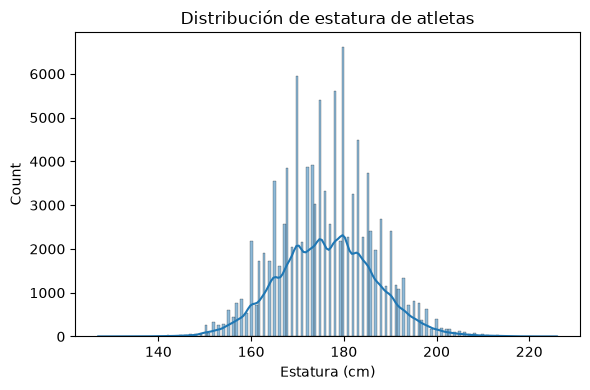

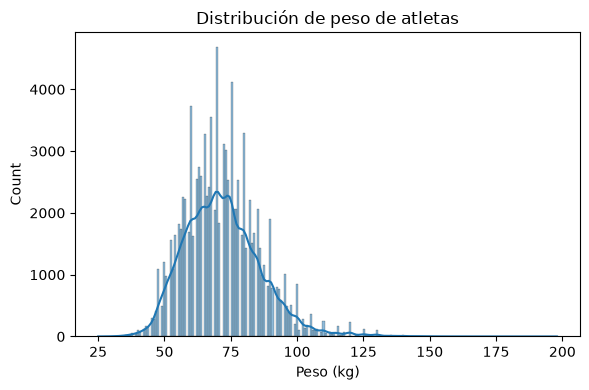

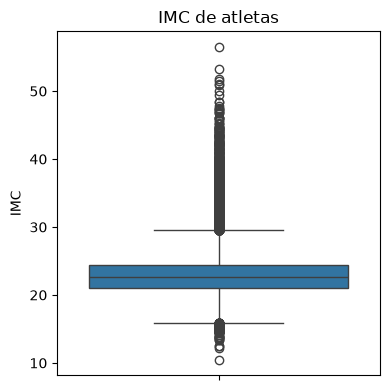

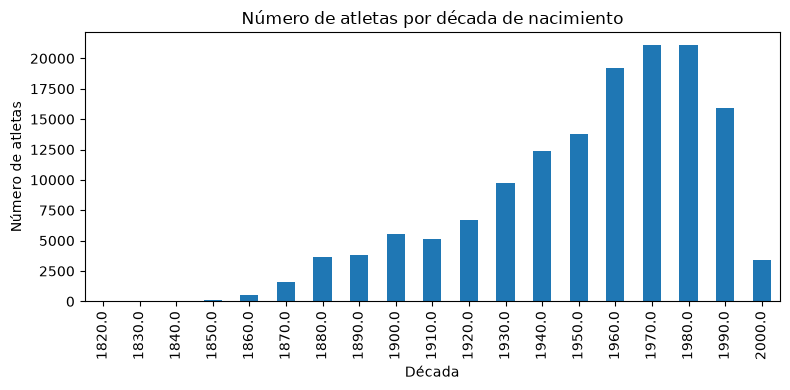

In [17]:
# Estadísticos básicos
bios_new[["Estatura_Cm", "Peso_Kg", "Edad", "IMC"]].describe()

# Top 10 países de nacimiento
print(bios_new["Pais_Nacimiento"].value_counts().head(10))

# Histograma de estatura
plt.figure(figsize=(6,4))
sns.histplot(bios_new["Estatura_Cm"].dropna(), kde=True)
plt.title("Distribución de estatura de atletas")
plt.xlabel("Estatura (cm)")
plt.tight_layout()
plt.show()

# Histograma de peso
plt.figure(figsize=(6,4))
sns.histplot(bios_new["Peso_Kg"].dropna(), kde=True)
plt.title("Distribución de peso de atletas")
plt.xlabel("Peso (kg)")
plt.tight_layout()
plt.show()

# Boxplot IMC
plt.figure(figsize=(4,4))
sns.boxplot(y=bios_new["IMC"])
plt.title("IMC de atletas")
plt.tight_layout()
plt.show()

# Conteo por década de nacimiento
plt.figure(figsize=(8,4))
bios_new["Decada_Nacimiento"].value_counts().sort_index().plot(kind="bar")
plt.title("Número de atletas por década de nacimiento")
plt.xlabel("Década")
plt.ylabel("Número de atletas")
plt.tight_layout()
plt.show()

Peso:
La distribución del peso es aproximadamente unimodal y con cola a la derecha.
La mayor concentración está alrededor de 60 a 80 kg.
Hay pocos atletas con pesos muy altos, lo que genera los valores extremos.

IMC:
El boxplot muestra una mediana alrededor de valores “normales” de IMC.
Hay muchos outliers altos, lo que sugiere atletas con constituciones muy distintas según el deporte.
También aparecen algunos valores bajos, aunque menos numerosos.



Estatura:
La distribución de estatura es bastante campaniforme.
La mayor concentración está alrededor de 170 a 185 cm.
Hay pocos atletas extremadamente bajos o altos.

Década de nacimiento:
La mayoría de atletas se concentra entre las décadas de 1960, 1970, 1980 y 1990.
Esto indica que la base está dominada por atletas nacidos en el siglo XX, con muy pocos registros en décadas anteriores.

El análisis descriptivo de la base 6 mostró que la estatura de los atletas presenta una distribución aproximadamente normal, con mayor concentración entre 170 y 185 cm. El peso también sigue una forma unimodal, aunque con sesgo hacia la derecha debido a la presencia de algunos valores altos. El IMC presenta numerosos valores atípicos, lo que sugiere diversidad corporal importante entre atletas de diferentes disciplinas.Además, la mayoría de los atletas nace entre las décadas de 1960 y 1990, y se observa una gran cantidad de registros con país de nacimiento desconocido. En conjunto, estos resultados reflejan una base internacional y heterogénea, con variabilidad física considerable entre los deportistas.

1) Correlación estatura–peso

Correlación estatura-peso (r): 0.7792903329719264
p: 0.0


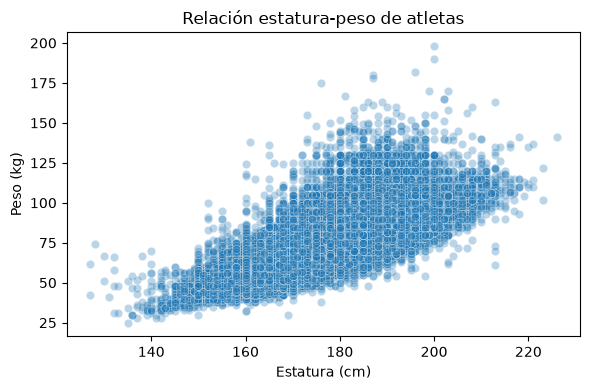

In [18]:
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt

# Filtro para evitar NaN
mask = bios_new["Estatura_Cm"].notna() & bios_new["Peso_Kg"].notna()

r_hw, p_hw = pearsonr(
    bios_new.loc[mask, "Estatura_Cm"],
    bios_new.loc[mask, "Peso_Kg"]
)

print("Correlación estatura-peso (r):", r_hw)
print("p:", p_hw)

# Gráfico de dispersión
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=bios_new,
    x="Estatura_Cm",
    y="Peso_Kg",
    alpha=0.3
)
plt.title("Relación estatura-peso de atletas")
plt.xlabel("Estatura (cm)")
plt.ylabel("Peso (kg)")
plt.tight_layout()
plt.show()

La relación es positiva y alta.

Como p es prácticamente cero, la relación es estadísticamente significativa.

En términos simples: atletas más altos tienden a pesar más, y esto se ve claramente en la nube de puntos.

2) Comparación por país (estatura por país de nacimiento)

Top países: Index(['USA', 'GER', 'GBR', 'FRA', 'ITA'], dtype='string', name='Pais_Nacimiento')


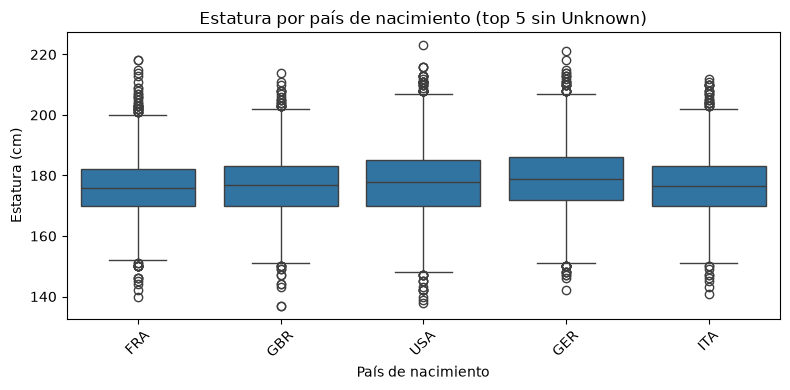

In [19]:
# Top países de nacimiento sin 'Unknown'
top_paises = (
    bios_new.loc[bios_new["Pais_Nacimiento"] != "Unknown", "Pais_Nacimiento"]
    .value_counts()
    .head(5)
    .index
)
print("Top países:", top_paises)

subset = bios_new[bios_new["Pais_Nacimiento"].isin(top_paises)]

plt.figure(figsize=(8, 4))
sns.boxplot(data=subset, x="Pais_Nacimiento", y="Estatura_Cm")
plt.title("Estatura por país de nacimiento (top 5 sin Unknown)")
plt.xlabel("País de nacimiento")
plt.ylabel("Estatura (cm)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

El boxplot sugiere que los países tienen distribuciones parecidas en mediana, pero con diferencias suficientes para que el ANOVA salga altamente significativo

In [20]:
from scipy.stats import f_oneway

grupos_estatura = [
    g["Estatura_Cm"].dropna().values
    for _, g in subset.groupby("Pais_Nacimiento")
]

F_pais, p_pais = f_oneway(*grupos_estatura)
print("F estatura por país:", F_pais)
print("p estatura por país:", p_pais)

F estatura por país: 58.3955772616672
p estatura por país: 3.908886866840484e-49


Hay diferencias muy significativas en la estatura media entre los países del top 5.

3) IMC y peso por país (top 5 sin Unknown)

Top países: Index(['USA', 'GER', 'GBR', 'FRA', 'ITA'], dtype='string', name='Pais_Nacimiento')


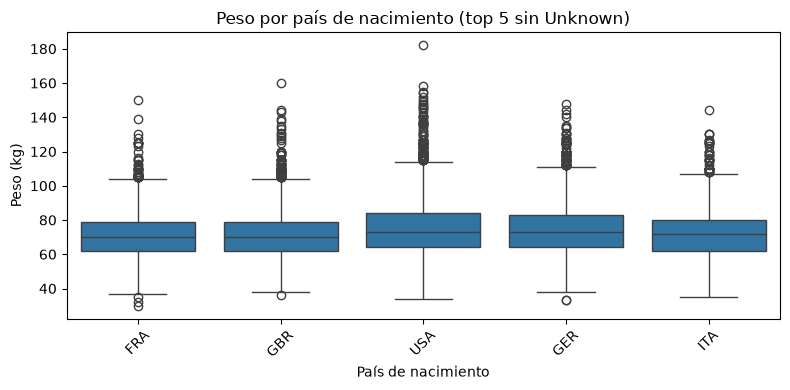

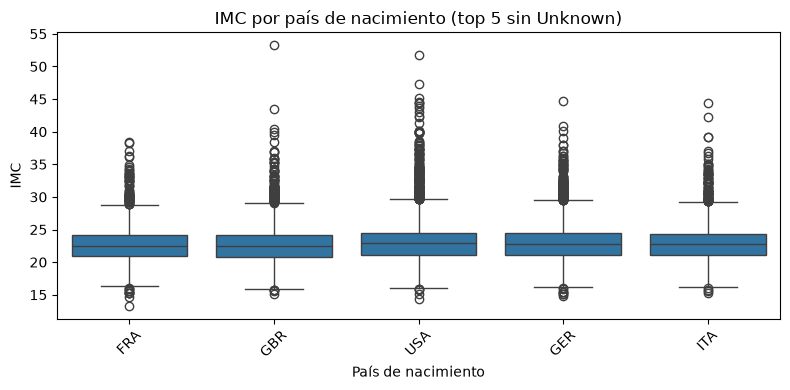

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Top países sin 'Unknown'
top_paises = (
    bios_new.loc[bios_new["Pais_Nacimiento"] != "Unknown", "Pais_Nacimiento"]
    .value_counts()
    .head(5)
    .index
)
print("Top países:", top_paises)

subset = bios_new[bios_new["Pais_Nacimiento"].isin(top_paises)]

# Boxplot de peso por país
plt.figure(figsize=(8, 4))
sns.boxplot(data=subset, x="Pais_Nacimiento", y="Peso_Kg")
plt.title("Peso por país de nacimiento (top 5 sin Unknown)")
plt.xlabel("País de nacimiento")
plt.ylabel("Peso (kg)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Boxplot de IMC por país
plt.figure(figsize=(8, 4))
sns.boxplot(data=subset, x="Pais_Nacimiento", y="IMC")
plt.title("IMC por país de nacimiento (top 5 sin Unknown)")
plt.xlabel("País de nacimiento")
plt.ylabel("IMC")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Los boxplots muestran que, aunque las medianas son parecidas, hay variación en la dispersión y bastantes valores extremos

In [22]:
from scipy.stats import f_oneway

grupos_imc = [
    g["IMC"].dropna().values
    for _, g in subset.groupby("Pais_Nacimiento")
]

F_imc, p_imc = f_oneway(*grupos_imc)
print("F IMC por país:", F_imc)
print("p IMC por país:", p_imc)

F IMC por país: 19.940202018548355
p IMC por país: 2.0920577323286862e-16


Hay diferencias estadísticamente significativas en el IMC entre los países del top 5.

4) Vivos vs fallecidos

In [23]:
bios_new["Estado_Vida"].value_counts()
bios_new["Estado_Vida"].value_counts(normalize=True)

Estado_Vida
Vivo         0.766735
Fallecido    0.233265
Name: proportion, dtype: float64

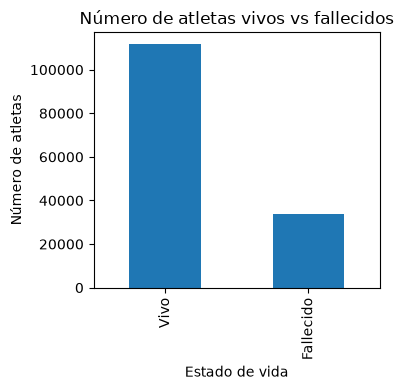

In [24]:
plt.figure(figsize=(4, 4))
bios_new["Estado_Vida"].value_counts().plot(kind="bar")
plt.title("Número de atletas vivos vs fallecidos")
plt.xlabel("Estado de vida")
plt.ylabel("Número de atletas")
plt.tight_layout()
plt.show()

El gráfico muestra claramente más atletas vivos que fallecidos en número absoluto, lo cual es coherente con la cantidad total de registros y con cómo se categoriza la variable.

Media edad vivos: 55.85388634998088
Media edad fallecidos: 70.9838094956717
t Edad vivos vs fallecidos: -138.34234264039492
p Edad vivos vs fallecidos: 0.0


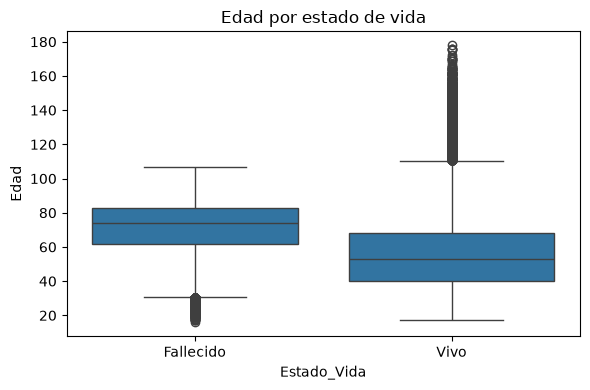

In [25]:
import scipy.stats as stats

edad_vivos = bios_new[bios_new["Estado_Vida"] == "Vivo"]["Edad"].dropna()
edad_falle = bios_new[bios_new["Estado_Vida"] == "Fallecido"]["Edad"].dropna()

print("Media edad vivos:", edad_vivos.mean())
print("Media edad fallecidos:", edad_falle.mean())

t_edad, p_edad = stats.ttest_ind(edad_vivos, edad_falle, equal_var=False)
print("t Edad vivos vs fallecidos:", t_edad)
print("p Edad vivos vs fallecidos:", p_edad)

# Boxplot de edad por estado de vida
plt.figure(figsize=(6, 4))
sns.boxplot(data=bios_new, x="Estado_Vida", y="Edad")
plt.title("Edad por estado de vida")
plt.tight_layout()
plt.show()

El boxplot indica que:
Los fallecidos tienen mayor edad mediana.
Los vivos se concentran en edades más bajas, aunque hay algunos muy longevos.
Eso era lo esperable y refuerza la coherencia de la variable Edad.